<h1 align="center">Traffic Management System Model</h1>
<p align="center">Used a lightgbm model with early stopping and reproducability to stop overfitting</p>

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error

In [2]:
#reproducability
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)

SEED = 42
seed_everything(SEED)

In [3]:
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

In [4]:
def clean_features(df, is_train=True, median_temp=None, mode_road=None, mode_weather=None):
    df = df.copy()

    if is_train:
        median_temp = df['Temperature'].median()
        mode_road = df['RoadType'].mode()[0]
        mode_weather = df['Weather'].mode()[0]
    
    df['Temperature'] = df['Temperature'].fillna(median_temp)
    df['RoadType'] = df['RoadType'].fillna(mode_road)
    df['Weather'] = df['Weather'].fillna(mode_weather)

    def timestamp_to_minutes(ts):
        try:
            h, m = map(int, str(ts).split(':'))
            return h * 60 + m
        except:
            return 0
            
    df['Minutes'] = df['timestamp'].apply(timestamp_to_minutes)
    df['Hour'] = df['Minutes'] // 60
    
    # Encode Categorical Features explicitly
    categorical_cols = ['geohash', 'RoadType', 'LargeVehicles', 'Landmarks', 'Weather']
    for col in categorical_cols:
        df[col] = df[col].astype('category')
        
    return df, median_temp, mode_road, mode_weather

In [5]:
df_train_cleaned, med_t, mode_r, mode_w = clean_features(df_train, is_train=True)
df_test_cleaned, _, _, _ = clean_features(df_test, is_train=False, median_temp=med_t, mode_road=mode_r, mode_weather=mode_w)

features = ['geohash', 'day', 'Minutes', 'Hour', 'RoadType', 'NumberofLanes', 'LargeVehicles', 'Landmarks', 'Temperature', 'Weather']
X = df_train_cleaned[features]
y = df_train_cleaned['demand']
X_test = df_test_cleaned[features]

In [12]:
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

oof_predictions = np.zeros(len(df_train_cleaned))
test_predictions = np.zeros(len(df_test_cleaned))

evals_result_list = []

params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 63,
    'max_depth': -1,
    'feature_fraction': 0.8,
    'verbose': -1,
    'seed': SEED,                  
    'deterministic': True,         
    'force_col_wise': True         
}

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
    
    train_data = lgb.Dataset(X_train, label=y_train)
    val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)
    
    evals_result = {}
    
    model = lgb.train(
        params,
        train_data,
        num_boost_round=1500,
        valid_sets=[train_data, val_data],
        valid_names=['train', 'valid'],
        callbacks=[
            lgb.record_evaluation(evals_result),
            lgb.early_stopping(stopping_rounds=50, verbose=False)
        ]
    )

In [13]:
evals_result_list.append(evals_result)
oof_predictions[val_idx] = model.predict(X_val, num_iteration=model.best_iteration)
test_predictions += model.predict(X_test, num_iteration=model.best_iteration) / kf.n_splits
print(f"Fold {fold+1} Finished.")

Fold 5 Finished.


RMSE: 0.153
Model R2 Score: -0.154
Calculated Score/Accuracy: -15.384%


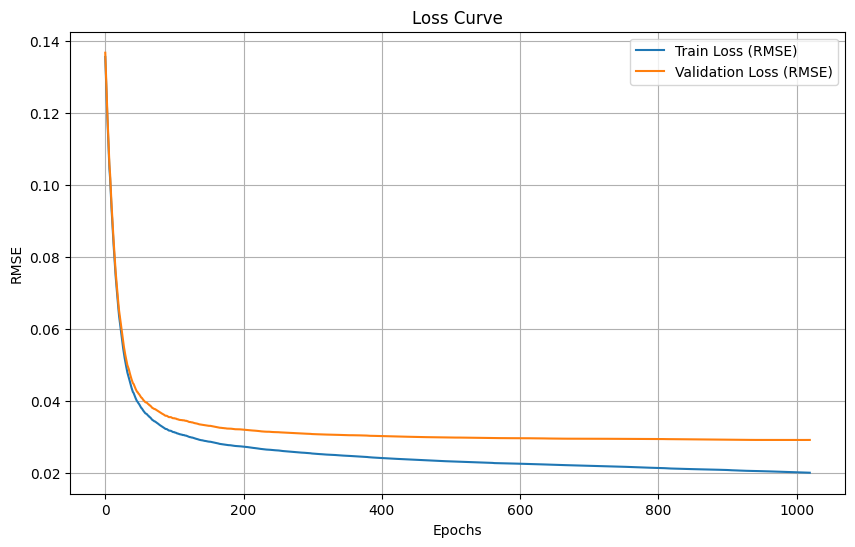

In [15]:
final_rmse = np.sqrt(mean_squared_error(y, oof_predictions))
final_r2 = r2_score(y, oof_predictions)
calculated_accuracy = final_r2 * 100 

print(f"RMSE: {final_rmse:.3f}")
print(f"Model R2 Score: {final_r2:.3f}")
print(f"Calculated Score/Accuracy: {calculated_accuracy:.3f}%")

plt.figure(figsize=(10, 6))
plt.plot(evals_result_list[0]['train']['rmse'], label='Train Loss (RMSE)')
plt.plot(evals_result_list[0]['valid']['rmse'], label='Validation Loss (RMSE)')
plt.xlabel('Epochs')
plt.ylabel('RMSE')
plt.title('Loss Curve')
plt.legend()
plt.grid(True)
plt.show()


In [18]:
submission = pd.DataFrame({
    'Index': df_test['Index'],
    'demand': test_predictions
})

submission.to_csv('prediction.csv', index=False)
print("Predictions saved to 'prediction.csv'.")

Predictions saved to 'prediction.csv'.
